# maps_to_grid/normal — one grid, three dynamical maps (full per-timestep pipeline)

This folder computes the **exact / approximate open-system dynamics** of the 4-site FMO model in a
single, uniform way: every method produces a *dynamical map* $\mathcal{L}(t)$ (a $16\times16$ matrix)
**at every saved time**, which the shared **grid** turns into Kraus operators $M_k(t)$ and propagates,
$\rho(t)=\sum_k M_k(t)\,\rho(0)\,M_k^\dagger(t)$ -- a *fresh* Choi/Kraus decomposition for every $t$.

This is the **normal** (non-enhanced) pipeline. It is fully self-contained: nothing here is shared
with `../enhanced/` (which reuses a single classically-computed operator instead of one per time step).

| file | what it is |
|---|---|
| `pathintegral_map.py` | TEMPO/TNPI path integral $\to \mathcal L(t)$ (numerically exact, non-Markovian). **Expensive.** |
| `heom_map.py` | HEOM map $\mathcal L(t)=[e^{\hat{\mathcal L}_{\rm HEOM}t}]_{\mathbf 0\mathbf 0}$ (exact) + standard HEOM run |
| `lindblad_map.py` | thesis secular-Redfield/GKSL map $\mathcal L(t)=e^{L t}$ (Markovian approx.) + standard mesolve |
| `grid.py` | Choi $\to$ Kraus $\to$ operator-sum propagation; save/load map files |
| `data/*.npz` | the precomputed maps $\mathcal L(t_k)$ for each method, full $0..1000$ fs trajectory |
| `pictures/*.png` | all figures this notebook produces |
| `run_and_plot.ipynb` | **this notebook**: load maps $\to$ grid $\to$ compare & plot |

**Why data files.** The path integral takes *hours*; recomputing it just to plot would be painful.
So each `*_map.py` **saves its maps to `data/…_maps.npz`** once, and this notebook only *reads* them —
plotting is instant. `data/pathintegral_maps.npz` was copied from the earlier production run, so the
path integral **never has to run again**. To regenerate the (cheap) HEOM/Lindblad maps run
`python heom_map.py` / `python lindblad_map.py`; to (re)compute the path integral run
`python pathintegral_map.py` (slow).

**How to choose what to plot:** edit the `to_plot` list below — comment out any line to hide that curve.

In [1]:
import os, sys
sys.path.insert(0, os.getcwd())  # run from this folder
os.makedirs('pictures', exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from grid import populations_via_kraus
import heom_map, lindblad_map

# initial state: excitation on site 1
d = 4
rho0 = np.zeros((d, d), complex); rho0[0, 0] = 1.0
t_fs = np.arange(0.0, 1001.0, 10.0)          # common grid (matches the data files)

# --- the 3 maps: read map file -> grid (Choi->Kraus) -> populations ---
results = {}
results['Path integral']  = populations_via_kraus('data/pathintegral_maps.npz', rho0)
results['HEOM (map)']     = populations_via_kraus('data/heom_maps.npz',        rho0)
results['Lindblad (map)'] = populations_via_kraus('data/lindblad_maps.npz',    rho0)

# --- the 2 standard implementations (direct solvers, no Kraus) ---
results['HEOM (standard)']     = {'t_fs': t_fs,
    'pops': heom_map.standard_heom_pops(t_fs, rho0)}
results['Lindblad (standard)'] = {'t_fs': t_fs,
    'pops': lindblad_map.standard_lindblad_pops(t_fs, rho0)}

# quick report
for name, r in results.items():
    p = r['pops'][-1]
    extra = ''
    if 'min_choi_eig' in r:
        extra = f"  minChoiEig={r['min_choi_eig'].min():+.1e}  #Kraus={r['n_kraus'].max()}"
    print(f"{name:20s} pops@1000fs = {np.round(p, 4)}{extra}")

10.0%. Run time:   0.08s. Est. time left: 00:00:00:00


20.0%. Run time:   0.11s. Est. time left: 00:00:00:00


30.0%. Run time:   0.14s. Est. time left: 00:00:00:00


40.0%. Run time:   0.17s. Est. time left: 00:00:00:00


50.0%. Run time:   0.21s. Est. time left: 00:00:00:00


...

80.0%. Run time:   0.29s. Est. time left: 00:00:00:00


90.0%. Run time:   0.32s. Est. time left: 00:00:00:00


100.0%. Run time:   0.35s. Est. time left: 00:00:00:00


Total run time:   0.35s


Path integral        pops@1000fs = [0.3812 0.2211 0.2469 0.1508]  minChoiEig=-6.7e-16  #Kraus=16
HEOM (map)           pops@1000fs = [0.3793 0.2197 0.2489 0.1521]  minChoiEig=-2.3e-10  #Kraus=16
Lindblad (map)       pops@1000fs = [0.2701 0.4655 0.1001 0.1643]  minChoiEig=-6.7e-16  #Kraus=16
HEOM (standard)      pops@1000fs = [0.3793 0.2197 0.2489 0.1521]
Lindblad (standard)  pops@1000fs = [0.2701 0.4655 0.1001 0.1643]


## Compare the methods

One panel per site; **one colour per method** (so methods never share a colour). Comment a line in
`to_plot` to hide that curve. Expected picture: **Path integral $\approx$ HEOM** (both numerically
exact); **Lindblad differs** (it is the Markovian approximation of the same bath); each `(map)` sits
exactly on top of its `(standard)` partner (a consistency check of the Kraus pipeline).

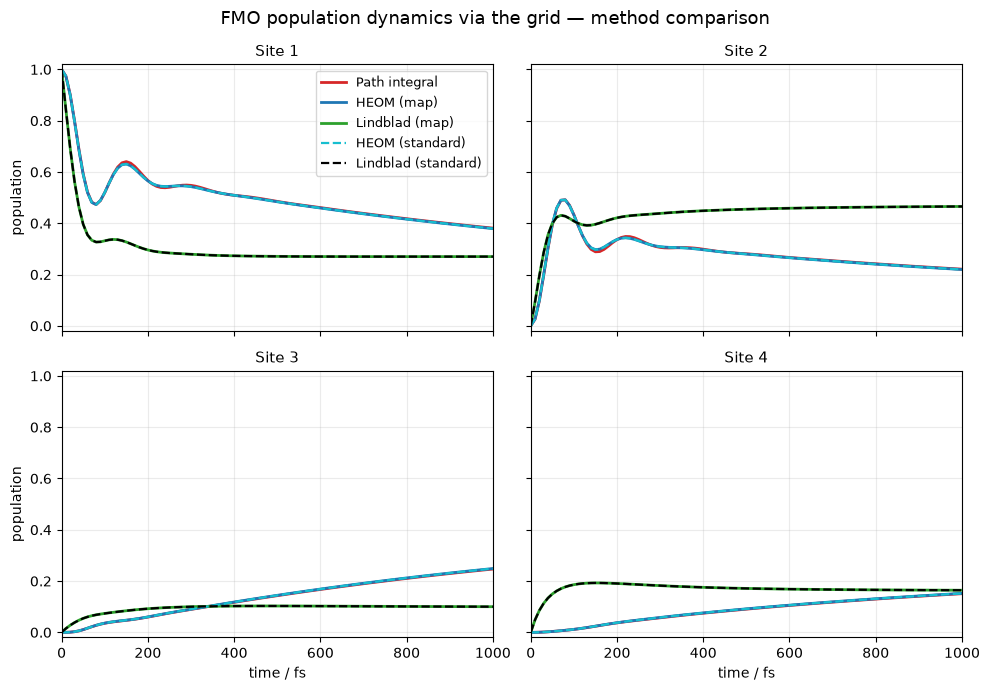

wrote pictures/maps_comparison.png


In [2]:
# ---- pick what to plot: comment out a line to hide that curve ----
to_plot = [
    'Path integral',
    'HEOM (map)',
    'Lindblad (map)',
    'HEOM (standard)',
    'Lindblad (standard)',
]

style = {  # one colour per method; (map) solid, (standard) dashed for the pairs
    'Path integral':       dict(color='#d62728', ls='-',  lw=2.0),
    'HEOM (map)':          dict(color='#1f77b4', ls='-',  lw=2.0),
    'Lindblad (map)':      dict(color='#2ca02c', ls='-',  lw=2.0),
    'HEOM (standard)':     dict(color='#17becf', ls='--', lw=1.6),
    'Lindblad (standard)': dict(color='#000000', ls='--', lw=1.6),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for site, ax in enumerate(axes.flat):
    for name in to_plot:
        r = results[name]
        ax.plot(r['t_fs'], r['pops'][:, site], label=name, **style[name])
    ax.set_title(f'Site {site + 1}', fontsize=11)
    ax.set_xlim(0, 1000); ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    if site >= 2: ax.set_xlabel('time / fs')
    if site % 2 == 0: ax.set_ylabel('population')
axes.flat[0].legend(fontsize=9, loc='upper right')
fig.suptitle('FMO population dynamics via the grid — method comparison', fontsize=13)
fig.tight_layout()
fig.savefig('pictures/maps_comparison.png', dpi=200)
plt.show()
print('wrote pictures/maps_comparison.png')

## Deviation from a reference (optional)

Same data, shown as $p_i^{\rm method}-p_i^{\rm ref}$ against a chosen reference — handy to see how far
the Lindblad approximation is, and to confirm the exact methods agree at the $10^{-2}$–$10^{-3}$ level
(path integral vs HEOM) while `(map)` vs `(standard)` agree at $10^{-8}$. Change `reference` or comment
lines in `diff_plot`.

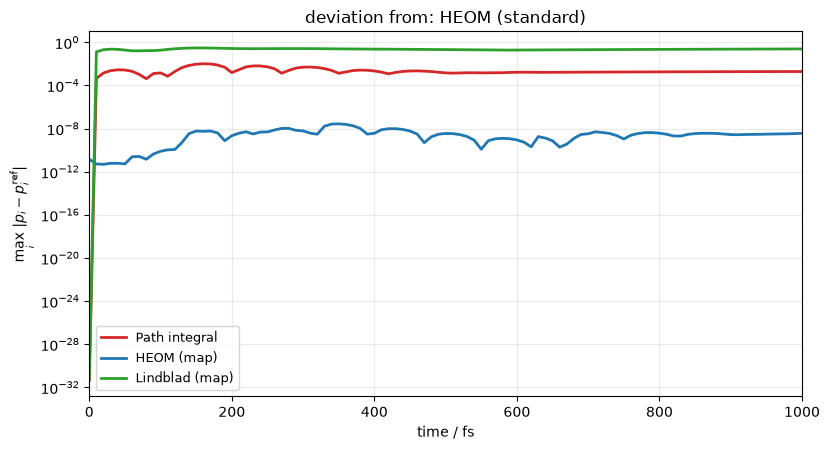

wrote pictures/maps_deviation.png


In [3]:
reference = 'HEOM (standard)'          # <- change the reference here
diff_plot = [
    'Path integral',
    'HEOM (map)',
    'Lindblad (map)',
    # 'Lindblad (standard)',
]

ref = results[reference]['pops']
fig, ax = plt.subplots(figsize=(8.4, 4.6))
for name in diff_plot:
    if name == reference:
        continue
    dp = results[name]['pops'] - ref
    ax.plot(t_fs, np.abs(dp).max(axis=1), label=f'{name}', **style[name])
ax.set_yscale('log')
ax.set_xlabel('time / fs'); ax.set_ylabel(r'$\max_i\,|p_i - p_i^{{\rm ref}}|$')
ax.set_title(f'deviation from: {reference}')
ax.set_xlim(0, 1000); ax.grid(alpha=0.25, which='both'); ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig('pictures/maps_deviation.png', dpi=200); plt.show()
print('wrote pictures/maps_deviation.png')

## Notes

* **Reuse:** all three `data/*.npz` are precomputed; this notebook never recomputes a map. Regenerate
  the cheap ones with `python heom_map.py` / `python lindblad_map.py`; the path integral with
  `python pathintegral_map.py` (slow — normally leave it).
* **Consistency of the pipeline:** `HEOM (map)` vs `HEOM (standard)` and `Lindblad (map)` vs
  `Lindblad (standard)` agree to $\sim10^{-8}$ — the Choi$\to$Kraus grid reproduces the direct solvers.
* **Physics:** Path integral and HEOM are numerically exact and agree; the thesis Lindblad is the
  Markovian (secular-Redfield) approximation and visibly deviates — exactly the comparison this folder
  is built to make.
* **CP monitor:** for the map-based results, `results[name]['min_choi_eig']` is the smallest Choi
  eigenvalue at each time ($\ge 0$ ⇒ completely positive; tiny negatives are truncation noise).
* **Change the model / initial state:** edit `rho0` (and the `H_FMO`/bath parameters inside the
  `*_map.py` files, then regenerate the data).
* **Enhanced algorithm:** for the "compute the map once, reuse it forever" approach (Markovian and
  memory-enhanced/non-Markovian variants), see the fully separate `../enhanced/` folder.